<a href="https://colab.research.google.com/github/mabdulatalhakh213-ux/Northstar/blob/main/Northstar_PY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

BG = "#f6f3ef"
PANEL = "#ffffff"
TEXT = "#1f2937"
MUTED = "#6b7280"
TEAL = "#0f766e"
TEAL2 = "#14b8a6"
GOLD = "#f59e0b"
RED = "#dc2626"
NAVY = "#1d4ed8"
SLATE = "#94a3b8"
GRID = "#e5e7eb"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": PANEL,
    "axes.edgecolor": PANEL,
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": TEXT,
    "ytick.color": TEXT,
    "text.color": TEXT,
    "grid.color": GRID,
    "grid.linestyle": "--",
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False
})

def clean_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.grid(axis="x", alpha=0.25)
    ax.grid(axis="y", alpha=0.12)

def title_block(ax, title, subtitle=""):
    ax.set_title(title, loc="left", fontsize=18, fontweight="bold", pad=14)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, fontsize=10.5, color=MUTED)

def safe_value_counts(df, col):
    return (
        df[col]
        .fillna("Unknown")
        .astype(str)
        .value_counts()
        .reset_index()
        .rename(columns={"index": col, col: "count"})
    )

In [19]:
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", font_scale=1.0)

base = "https://raw.githubusercontent.com/mabdulatalhakh213-ux/Northstar/main/"

customers  = pd.read_csv(base + "customers.csv")
orders     = pd.read_csv(base + "orders.csv")
deliveries = pd.read_csv(base + "deliveries.csv")
complaints = pd.read_csv(base + "complaints.csv")
app_events = pd.read_csv(base + "app_events.csv")
drivers    = pd.read_csv(base + "drivers.csv")
incidents  = pd.read_csv(base + "incidents.csv")
hubs       = pd.read_csv(base + "hubs.csv")
vehicles   = pd.read_csv(base + "vehicles.csv")

print("All CSV files loaded successfully")
print("deliveries:", deliveries.shape)
print("complaints:", complaints.shape)
print("app_events:", app_events.shape)
print("incidents:", incidents.shape)
display(deliveries.head())

All CSV files loaded successfully
deliveries: (950, 13)
complaints: (320, 10)
app_events: (640, 10)
incidents: (280, 7)


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [20]:
def clean_columns(df):
    df.columns = (
        df.columns
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "", regex=False)
        .str.replace("_", "", regex=False)
    )
    return df

customers  = clean_columns(customers)
orders     = clean_columns(orders)
deliveries = clean_columns(deliveries)
complaints = clean_columns(complaints)
app_events = clean_columns(app_events)
drivers    = clean_columns(drivers)
incidents  = clean_columns(incidents)
hubs       = clean_columns(hubs)
vehicles   = clean_columns(vehicles)

print("ORDERS COLUMNS:")
print(orders.columns.tolist())

print("\nDELIVERIES COLUMNS:")
print(deliveries.columns.tolist())

print("\nCOMPLAINTS COLUMNS:")
print(complaints.columns.tolist())

print("\nAPP_EVENTS COLUMNS:")
print(app_events.columns.tolist())

ORDERS COLUMNS:
['orderid', 'customerid', 'servicetype', 'ordercreatedat', 'promisedwindowhours', 'pickupzone', 'dropoffzone', 'prioritylevel', 'ordervalue', 'bookingchannel', 'specialhandlingflag']

DELIVERIES COLUMNS:
['deliveryid', 'orderid', 'driverid', 'vehicleid', 'hubid', 'dispatchtime', 'deliverycompletedat', 'deliverystatus', 'routedistancekm', 'manualrouteoverridecount', 'proofofcompletionmissing', 'customerratingpostdelivery', 'fuelorchargecost']

COMPLAINTS COLUMNS:
['complaintid', 'customerid', 'orderid', 'complainttype', 'channel', 'severity', 'createdat', 'status', 'resolutiondays', 'compensationamount']

APP_EVENTS COLUMNS:
['eventid', 'customerid', 'orderid', 'eventtimestamp', 'eventtype', 'sessionid', 'devicetype', 'zonecontext', 'apilatencyms', 'successflag']


In [21]:
def to_datetime_if_exists(df, col):
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

def to_numeric_if_exists(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

to_datetime_if_exists(orders, "createdat")
to_datetime_if_exists(deliveries, "dispatchtime")
to_datetime_if_exists(deliveries, "deliverycompletedat")
to_datetime_if_exists(complaints, "createdat")
to_datetime_if_exists(app_events, "eventtimestamp")
to_datetime_if_exists(incidents, "reportedat")
to_datetime_if_exists(vehicles, "commissiondate")

to_numeric_if_exists(orders, ["ordervalue", "promisedwindowhours"])
to_numeric_if_exists(deliveries, ["routedistancekm", "manualrouteoverridecount", "customerratingpostdelivery", "fuelorchargecost"])
to_numeric_if_exists(complaints, ["resolutiondays", "compensationamount"])
to_numeric_if_exists(app_events, ["apilatencyms", "successflag"])
to_numeric_if_exists(drivers, ["yearsexperience", "trainingscore", "driverrating", "activeflag"])
to_numeric_if_exists(incidents, ["resolvedhours"])
to_numeric_if_exists(vehicles, ["batteryhealthpct", "odometerkm"])

if "dispatchtime" in deliveries.columns and "deliverycompletedat" in deliveries.columns:
    deliveries["deliverydurationhours"] = (
        deliveries["deliverycompletedat"] - deliveries["dispatchtime"]
    ).dt.total_seconds() / 3600
    deliveries.loc[deliveries["deliverydurationhours"] < 0, "deliverydurationhours"] = np.nan

if "deliverystatus" in deliveries.columns:
    deliveries["isfailed"] = (deliveries["deliverystatus"].astype(str).str.lower() == "failed").astype(int)
    deliveries["isdelayed"] = (deliveries["deliverystatus"].astype(str).str.lower() == "delayed").astype(int)
    deliveries["isontime"] = (deliveries["deliverystatus"].astype(str).str.lower() == "ontime").astype(int)

print("Data cleaning complete")
display(orders.head())
display(deliveries.head())

Data cleaning complete


,orderid,customerid,servicetype,ordercreatedat,promisedwindowhours,pickupzone,dropoffzone,prioritylevel,ordervalue,bookingchannel,specialhandlingflag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


,deliveryid,orderid,driverid,vehicleid,hubid,dispatchtime,deliverycompletedat,deliverystatus,routedistancekm,manualrouteoverridecount,proofofcompletionmissing,customerratingpostdelivery,fuelorchargecost,deliverydurationhours,isfailed,isdelayed,isontime
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,22.149973,1,0,0
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,NaN,0,0,1
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,1.108991,0,0,1
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,23.985584,0,1,0
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,4.042814,0,0,1


In [22]:
print("Orders missing values:")
print(orders.isna().sum().sort_values(ascending=False).head(10))

print("\nDeliveries status counts:")
if "deliverystatus" in deliveries.columns:
    print(deliveries["deliverystatus"].value_counts(dropna=False))

print("\nNumeric summary for deliveries:")
delivery_numeric_cols = [c for c in ["deliverydurationhours", "routedistancekm", "manualrouteoverridecount", "customerratingpostdelivery", "fuelorchargecost"] if c in deliveries.columns]
print(deliveries[delivery_numeric_cols].describe())

Orders missing values:
bookingchannel         25
customerid              0
orderid                 0
servicetype             0
ordercreatedat          0
pickupzone              0
promisedwindowhours     0
dropoffzone             0
prioritylevel           0
ordervalue              0
dtype: int64

Deliveries status counts:
deliverystatus
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64

Numeric summary for deliveries:
       deliverydurationhours  routedistancekm  manualrouteoverridecount  \
count             867.000000       950.000000                950.000000   
mean               10.317151        13.909316                  0.969474   
std                 8.463124         7.477907                  1.093189   
min                 0.022565         1.200000                  0.000000   
25%                 3.501689         9.135000                  0.000000   
50%                 7.913109        12.840000                  1.000000   
75%                15.528078     

In [23]:
if {"hubid", "deliveryid", "deliverydurationhours", "isfailed", "isdelayed"}.issubset(deliveries.columns):
    hub_perf = (
        deliveries.groupby("hubid")
        .agg(
            totaldeliveries=("deliveryid", "count"),
            avgdeliveryhours=("deliverydurationhours", "mean"),
            failurerate=("isfailed", "mean"),
            delayrate=("isdelayed", "mean"),
            avgoverrides=("manualrouteoverridecount", "mean"),
            avgcustomerrating=("customerratingpostdelivery", "mean")
        )
        .reset_index()
    )

    if "hubid" in hubs.columns:
        hub_perf = hub_perf.merge(hubs, on="hubid", how="left")

    hub_perf["failurerate"] = hub_perf["failurerate"] * 100
    hub_perf["delayrate"] = hub_perf["delayrate"] * 100
    hub_perf = hub_perf.sort_values(["failurerate", "delayrate"], ascending=False)

    print("Hub performance")
    display(hub_perf.head(10))

Hub performance


,hubid,totaldeliveries,avgdeliveryhours,failurerate,delayrate,avgoverrides,avgcustomerrating,hubname,zone,hubtype,capacityscore
7,H08,128,10.560490,20.312500,17.187500,1.109375,3.884560,Midtown Relay,Central,Charging,63
4,H05,115,11.553300,20.000000,21.739130,0.947826,3.669558,Central Core,Central,Control,88
5,H06,104,9.917423,14.423077,25.961538,0.913462,3.882136,Airport Hub,Airport,Dispatch,71
3,H04,127,11.102635,12.598425,22.047244,0.874016,3.915476,West Gate,West,Dispatch,69
0,H01,136,10.684968,12.500000,19.117647,1.029412,3.840593,North Exchange,North,Dispatch,82
6,H07,115,10.535888,12.173913,21.739130,1.052174,3.881858,Riverside Hub,Riverside,Warehouse,66
1,H02,106,9.478948,9.433962,24.528302,0.915094,3.950952,South Link,South,Dispatch,78
2,H03,119,8.437893,9.243697,19.327731,0.890756,3.895862,East Dock,East,Warehouse,74


In [24]:
if "driverid" in deliveries.columns and "driverid" in drivers.columns:
    driver_risk = (
        deliveries.merge(drivers, on="driverid", how="left")
        .groupby(["driverid"] + ([ "employmenttype" ] if "employmenttype" in drivers.columns else []), dropna=False)
        .agg(
            totaljobs=("deliveryid", "count"),
            failedjobs=("isfailed", "sum"),
            delayedjobs=("isdelayed", "sum"),
            avgrating=("customerratingpostdelivery", "mean"),
            avgoverride=("manualrouteoverridecount", "mean")
        )
        .reset_index()
    )

    driver_risk = driver_risk[driver_risk["totaljobs"] >= 5]
    driver_risk = driver_risk.sort_values(["failedjobs", "avgrating"], ascending=[False, True])

    print("Driver risk ranking")
    display(driver_risk.head(15))

Driver risk ranking


,driverid,employmenttype,totaljobs,failedjobs,delayedjobs,avgrating,avgoverride
132,D133,Contract,12,4,2,3.423333,0.916667
23,D024,PartTime,8,4,0,3.443750,1.125000
103,D104,FullTime,7,4,0,3.928571,1.714286
91,D092,FullTime,5,3,0,3.376000,0.400000
3,D004,PartTime,9,3,1,3.510000,0.777778
130,D131,FullTime,9,3,2,3.655556,1.666667
54,D055,FullTime,10,3,2,3.813000,1.100000
82,D083,FullTime,9,3,1,3.910000,1.000000
9,D010,FullTime,7,3,0,4.145714,0.857143
107,D108,FullTime,11,3,0,4.411818,1.363636


In [25]:
digital_friction = (
    app_events.groupby(["devicetype","eventtype"])
    .agg(
        total_events=("eventid","count"),
        avg_latency_ms=("apilatencyms","mean"),
        success_rate=("successflag","mean")
    )
    .reset_index()
    .sort_values("avg_latency_ms", ascending=False)
)

digital_friction["success_rate"] *= 100

print("Digital friction")
display(digital_friction.head(15))

Digital friction


,devicetype,eventtype,total_events,avg_latency_ms,success_rate
18,iOS,chat_opened,37,535.378378,100.000000
13,Web,payment_retry,10,534.300000,90.000000
15,Web,track_order,25,533.320000,100.000000
1,Android,chat_escalated,16,532.750000,37.500000
9,Web,chat_escalated,8,526.500000,37.500000
3,Android,delivery_instruction_update,37,519.513514,100.000000
19,iOS,delivery_instruction_update,29,501.379310,100.000000
12,Web,eta_refresh,16,472.062500,100.000000
22,iOS,search_route,34,471.941176,100.000000
21,iOS,payment_retry,25,464.240000,72.000000


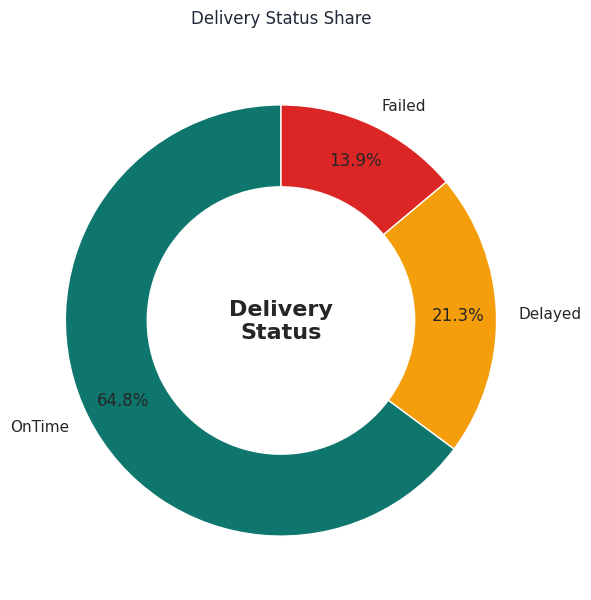

In [26]:
status_counts = deliveries["deliverystatus"].value_counts()

fig, ax = plt.subplots(figsize=(7,7))
colors = ["#0f766e", "#f59e0b", "#dc2626", "#94a3b8"]

ax.pie(
    status_counts.values,
    labels=status_counts.index,
    colors=colors[:len(status_counts)],
    startangle=90,
    wedgeprops=dict(width=0.38, edgecolor="white"),
    autopct="%1.1f%%",
    pctdistance=0.82
)
ax.text(0, 0, "Delivery\nStatus", ha="center", va="center", fontsize=16, fontweight="bold")
ax.set_title("Delivery Status Share", pad=20)
plt.show()

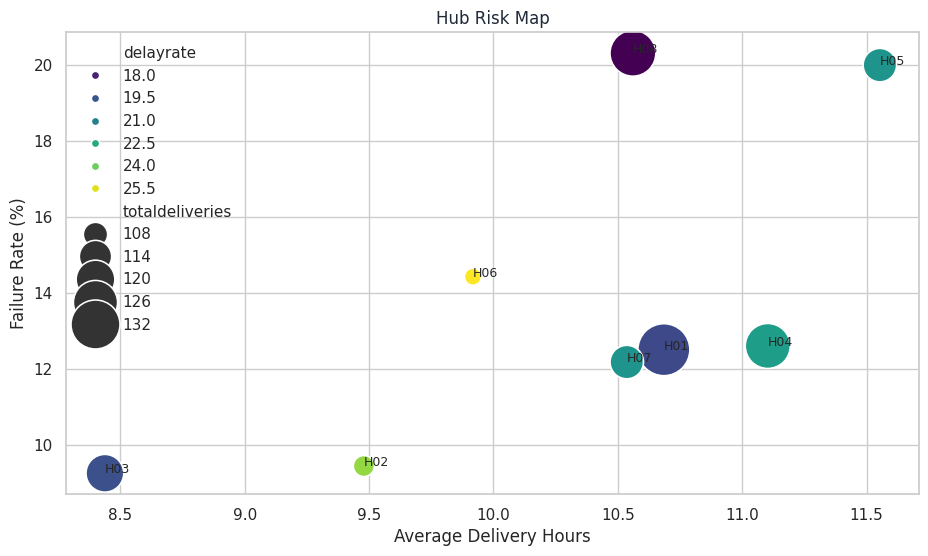

In [27]:
if "hub_perf" in globals():
    plt.figure(figsize=(11, 6))
    sns.scatterplot(
        data=hub_perf,
        x="avgdeliveryhours",
        y="failurerate",
        size="totaldeliveries",
        hue="delayrate",
        palette="viridis",
        sizes=(150, 1400)
    )

    for _, row in hub_perf.iterrows():
        plt.text(row["avgdeliveryhours"], row["failurerate"], str(row["hubid"]), fontsize=9)

    plt.title("Hub Risk Map")
    plt.xlabel("Average Delivery Hours")
    plt.ylabel("Failure Rate (%)")
    plt.show()

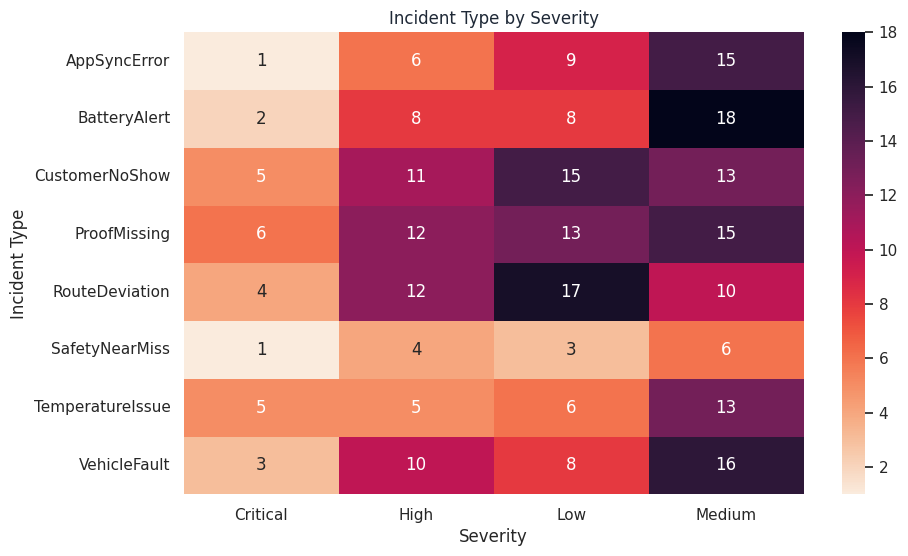

In [28]:
incident_heat = incidents.pivot_table(
    index="incidenttype",
    columns="severity",
    values="incidentid",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(10,6))
sns.heatmap(incident_heat, annot=True, cmap="rocket_r", fmt="g")
plt.title("Incident Type by Severity")
plt.xlabel("Severity")
plt.ylabel("Incident Type")
plt.show()

/tmp/ipykernel_12324/480449659.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=complaint_mix, x="count", y="complainttype", palette="mako")


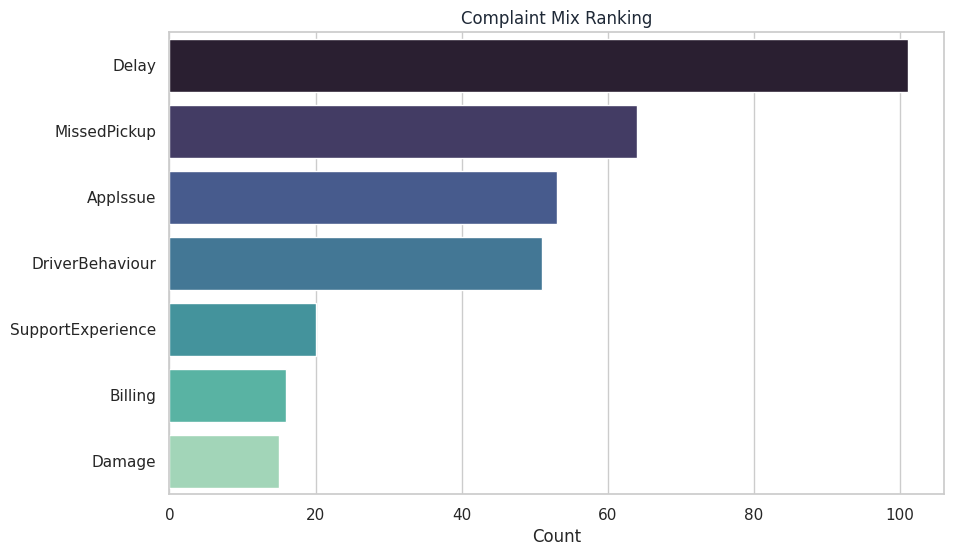

In [29]:
complaint_mix = complaints["complainttype"].value_counts().reset_index()
complaint_mix.columns = ["complainttype","count"]

plt.figure(figsize=(10,6))
sns.barplot(data=complaint_mix, x="count", y="complainttype", palette="mako")
plt.title("Complaint Mix Ranking")
plt.xlabel("Count")
plt.ylabel("")
plt.show()